In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [111]:
df_book = pd.read_csv("../data/raw/book/Books.csv", sep=";")
df_rating = pd.read_csv("../data/raw/book/Ratings.csv", sep=";")
df_user = pd.read_csv("../data/raw/book/Users.csv", sep=";")

C:\Users\aditya.kaushal\AppData\Local\Temp\ipykernel_83180\3541953899.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_user = pd.read_csv("../data/raw/book/Users.csv", sep=";")


#

# Books 


In [59]:
df_book.head()

,ISBN,Title,Author,Year,Publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton & Company


In [60]:
print('Book data nulls:-\n',df_book.info())
print()
print('Rating data nulls:-\n',df_rating.info())
print()
print('Users data nulls:-\n',df_user.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271379 entries, 0 to 271378
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   ISBN       271379 non-null  object
 1   Title      271379 non-null  object
 2   Author     271377 non-null  object
 3   Year       271379 non-null  int64 
 4   Publisher  271377 non-null  object
dtypes: int64(1), object(4)
memory usage: 10.4+ MB
Book data nulls:-
 None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column   Non-Null Count    Dtype 
---  ------   --------------    ----- 
 0   User-ID  1149780 non-null  int64 
 1   ISBN     1149780 non-null  object
 2   Rating   1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB
Rating data nulls:-
 None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278859 entries, 0 to 278858
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
-

In [61]:
print('Book data nulls:-\n',df_book.isnull().sum())
print()
print('Rating data nulls:-\n',df_rating.isnull().sum())
print()
print('Users data nulls:-\n',df_user.isnull().sum())

Book data nulls:-
 ISBN         0
Title        0
Author       2
Year         0
Publisher    2
dtype: int64

Rating data nulls:-
 User-ID    0
ISBN       0
Rating     0
dtype: int64

Users data nulls:-
 User-ID         0
Age        110232
dtype: int64


In [62]:
df_book.dropna(inplace=True)


In [63]:
# Check for total number of duplicate rows
duplicates_book = df_book.duplicated().sum()
print(f"Duplicate rows: {duplicates_book}")
duplicates_rating = df_user.duplicated().sum()
print(f"Duplicate rows: {duplicates_rating}")
duplicates_user = df_rating.duplicated().sum()
print(f"Duplicate rows: {duplicates_user}")


Duplicate rows: 1
Duplicate rows: 0
Duplicate rows: 0


In [64]:
# Drop duplicate rows permanently
df_book.drop_duplicates(inplace=True)

# This removes the 1 duplicate row from df_book in-place.


In [65]:
df_rating.head()

,User-ID,ISBN,Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [66]:
df_user.head()
df_user.describe()

,User-ID,Age
count,278859,168627
unique,278859,311
top,1,24
freq,1,5651


In [67]:
df_book.head()

,ISBN,Title,Author,Year,Publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton & Company


# Books

In [68]:
df_book.info()

<class 'pandas.core.frame.DataFrame'>
Index: 271374 entries, 0 to 271378
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   ISBN       271374 non-null  object
 1   Title      271374 non-null  object
 2   Author     271374 non-null  object
 3   Year       271374 non-null  int64 
 4   Publisher  271374 non-null  object
dtypes: int64(1), object(4)
memory usage: 12.4+ MB


## Checking author 

In [69]:
# Detect rows where author name is fully numeric
invalid_authors = df_book[df_book['Author'].str.isnumeric()]

# Count them
print(f"Invalid (numeric-only) author names: {len(invalid_authors)}")

# View a few examples
print(invalid_authors[['ISBN', 'Author']].head())


Invalid (numeric-only) author names: 0
Empty DataFrame
Columns: [ISBN, Author]
Index: []


In [70]:
df_book['Year'].describe()

count    271374.000000
mean       1959.755327
std         258.013684
min           0.000000
25%        1989.000000
50%        1995.000000
75%        2000.000000
max        2050.000000
Name: Year, dtype: float64

<Axes: xlabel='Year', ylabel='Count'>

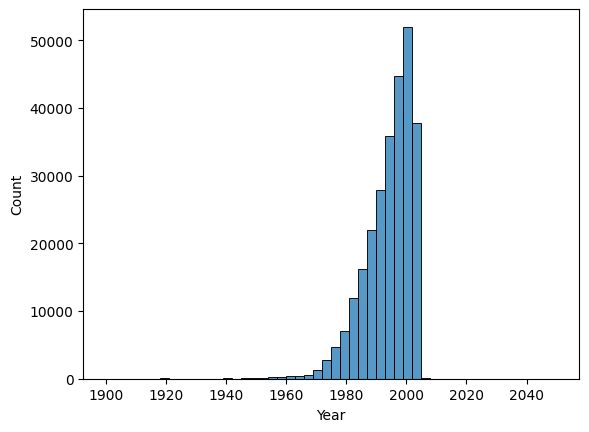

In [71]:
sns.histplot(df_book[df_book['Year'].between(1900, 2050)]['Year'], bins=50)


In [72]:
# Count of books published before 1900
before_1900 = df_book[df_book['Year'] ==0].shape[0]

# Count of books with year after 2025
after_2025 = df_book[df_book['Year'] > 2025].shape[0]

print(f"Books with year =0 : {before_1900}")
print(f"Books with year > 2025: {after_2025}")


Books with year =0 : 4619
Books with year > 2025: 12


- From this we can see that there are the many cells which contain the many 0 values means we dont know the year of publishing of that book 
- Most of the book published in the year of 1995 to 2015.
- There are some books which marked the year even after current year so that might be the wrong.

In [73]:
df_book[df_book['Year'] >2025].head(800)

,ISBN,Title,Author,Year,Publisher
37488,0671746103,MY TEACHER FRIED MY BRAINS (RACK SIZE) (MY TEA...,Coville,2030,Aladdin
55679,0671791990,MY TEACHER FLUNKED THE PLANET (RACK SIZE) (MY ...,Bruce Coville,2030,Aladdin
78171,0870449842,Crossing America,National Geographic Society,2030,National Geographic
80267,0140301690,Alice's Adventures in Wonderland and Through t...,Lewis Carroll,2050,Puffin Books
97830,0140201092,Outline of European Architecture (Pelican S.),Nikolaus Pevsner,2050,Penguin USA
116058,0394701658,Three Plays of Eugene Oneill,Eugene O'Neill,2038,Vintage Books USA
118299,3442436893,Das groÃ?Â?e BÃ?Â¶se- MÃ?Â¤dchen- Lesebuch.,Kathy Lette,2026,Goldmann
193004,0870446924,"Field Guide to the Birds of North America, 3rd...",National Geographic Society,2030,National Geographic
228187,0671266500,FOREST PEOPLE (Touchstone Books (Hardcover)),Colin M. Turnbull,2030,Simon & Schuster
240184,0684718022,In Our Time: Stories (Scribner Classic),Ernest Hemingway,2030,Collier Books


In [74]:
df_book[df_book['Year'] ==0].head(800)

,ISBN,Title,Author,Year,Publisher
176,3150000335,Kabale Und Liebe,Schiller,0,"Philipp Reclam, Jun Verlag GmbH"
188,342311360X,Die Liebe in Den Zelten,Gabriel Garcia Marquez,0,Deutscher Taschenbuch Verlag (DTV)
288,0571197639,Poisonwood Bible Edition Uk,Barbara Kingsolver,0,Faber Faber Inc
351,3596214629,"Herr Der Fliegen (Fiction, Poetry and Drama)",Golding,0,Fischer Taschenbuch Verlag GmbH
542,8845229041,Biblioteca Universale Rizzoli: Sulla Sponda De...,P Coelho,0,Fabbri - RCS Libri
...,...,...,...,...,...
45904,2290044369,Le Champ De Personne,Daniel Picouly,0,Editions 84
45905,227711006X,Chiens Perdus Sans Collier,Gilbert Cesbron,0,Jai Lu French
45957,B000051WXP,Emma,Jane Austen,0,Random House
46055,0739408909,Special Circumstances,Sheldon Siegel,0,Bantam Books


In [75]:
df_book.info()

<class 'pandas.core.frame.DataFrame'>
Index: 271374 entries, 0 to 271378
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   ISBN       271374 non-null  object
 1   Title      271374 non-null  object
 2   Author     271374 non-null  object
 3   Year       271374 non-null  int64 
 4   Publisher  271374 non-null  object
dtypes: int64(1), object(4)
memory usage: 12.4+ MB


## Correcting the year column from the internet

In [76]:

# Dictionary of correct years by ISBN
corrections = {
    "0671746103": 1991,
    "0671791990": 1992,
    "0870449842": 1999,
    "0140301690": 1950,
    "0140201092": 1950,
    "0394701658": 1959,
    "0684718022": 1925,
    "068471809X": 1937,
    "0870446924": 2003,
    "0671266500": 1961,
    "3442436893": 2023,
    "0671740989": 1943
}

# Apply corrections
df_book["Year"] = df_book.apply(
    lambda row: corrections.get(row["ISBN"], row["Year"]),
    axis=1
)


- Correctly impute the data with the correct value.

# Ratings

In [77]:
df_rating.head()

,User-ID,ISBN,Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [78]:
df_rating.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column   Non-Null Count    Dtype 
---  ------   --------------    ----- 
 0   User-ID  1149780 non-null  int64 
 1   ISBN     1149780 non-null  object
 2   Rating   1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


In [79]:
# Count of unique rating values
unique_rating_count = df_rating['Rating'].nunique()
print(f"Unique rating values: {unique_rating_count}")


Unique rating values: 11


In [80]:
print(df_rating['Rating'].value_counts().sort_index())



Rating
0     716109
1       1770
2       2759
3       5996
4       8904
5      50974
6      36924
7      76457
8     103736
9      67541
10     78610
Name: count, dtype: int64


- Zero means the user interacted with the book but not rated it.
- while building the model we have accordingly take this data in the picture.                          

## Converting the rating from 1-10 scale to 1-5

In [81]:
# Apply only to ratings > 0
df_rating['Rating'] = df_rating['Rating'].apply(
    lambda x: round((x / 10) * 5, 2) if x > 0 else 0
)


In [82]:
print(df_rating['Rating'].value_counts().sort_index())


Rating
0.0    716109
0.5      1770
1.0      2759
1.5      5996
2.0      8904
2.5     50974
3.0     36924
3.5     76457
4.0    103736
4.5     67541
5.0     78610
Name: count, dtype: int64


# User

In [83]:
df_user

,User-ID,Age
0,1,NaN
1,2,18
2,3,NaN
3,4,17
4,5,NaN
...,...,...
278854,278854,NaN
278855,278855,50
278856,278856,NaN
278857,278857,NaN


In [84]:
df_user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278859 entries, 0 to 278858
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   User-ID  278859 non-null  object
 1   Age      168627 non-null  object
dtypes: object(2)
memory usage: 4.3+ MB


## converting to the numerical cols 

In [85]:
# Step 1: Remove leading/trailing spaces (if any)
df_user['Age'] = df_user['Age'].str.strip()

# Step 2: Convert to numeric, forcing non-numeric values to NaN
df_user['Age'] = pd.to_numeric(df_user['Age'], errors='coerce')


KeyboardInterrupt: 

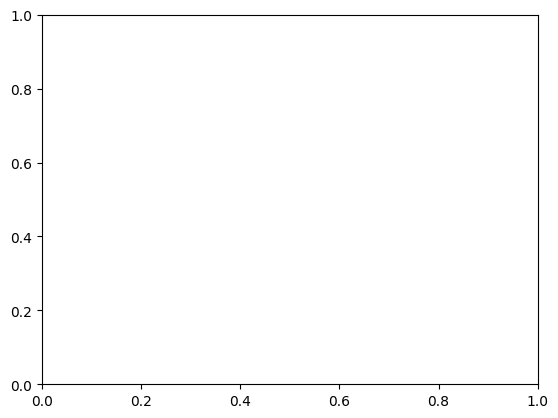

In [86]:
sns.histplot(df_user['Age'], bins=20, kde=True, edgecolor='black', color='green')


- From this we can see that there are the data where are is filled more that 120 which is the most rare case than in that case we have to analyze it properly.

In [ ]:
df_user

,User-ID,Age
0,1,NaN
1,2,18.0
2,3,NaN
3,4,17.0
4,5,NaN
...,...,...
278854,278854,NaN
278855,278855,50.0
278856,278856,NaN
278857,278857,NaN


In [ ]:
df_user[df_user['Age'] > 100].head()


,User-ID,Age
1288,1289,103.0
1322,1323,104.0
1578,1579,231.0
3084,3085,104.0
3210,3211,119.0


# Trimming the age


In [ ]:
# This line already modifies df_user directly
df_user.loc[df_user['Age'] > 110, 'Age'] = np.nan


- According to the google the after 110 there is very rare chance that someone can live so i took the cap of 110 and above that i marked as the nan.

<Axes: xlabel='Age', ylabel='Count'>

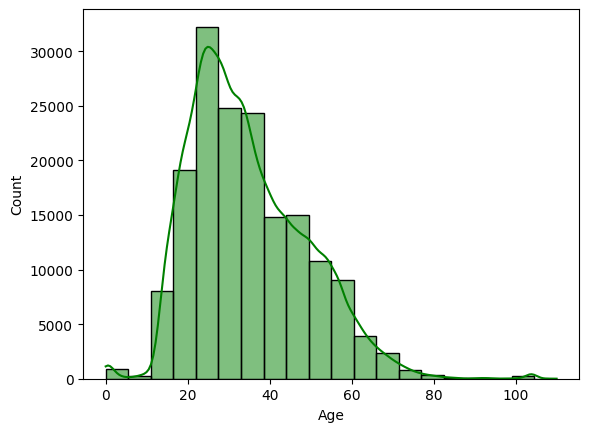

In [ ]:
sns.histplot(df_user['Age'], bins=20, kde=True, edgecolor='black', color='green')


In [ ]:
df_user[(df_user['Age'] >= 1) & (df_user['Age'] <= 5)].count()


User-ID    483
Age        483
dtype: int64

sns.histplot(df_user['Age'], bins=20, kde=True, edgecolor='black', color='green')


In [ ]:
df_user.loc[df_user['Age'] < 5, 'Age'] = 0


- As per the google minimum age is 5 to read the books.

<Axes: xlabel='Age', ylabel='Count'>

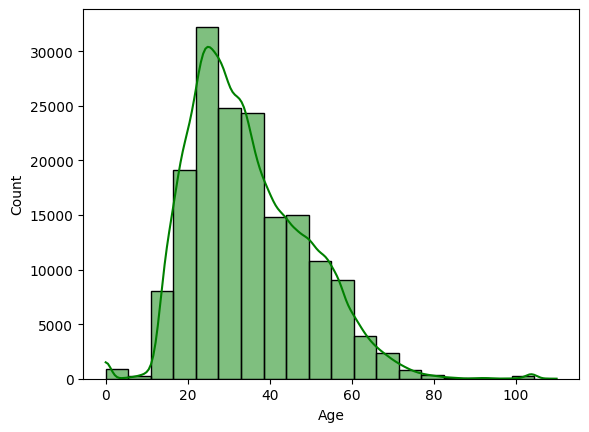

In [ ]:
sns.histplot(df_user['Age'], bins=20, kde=True, edgecolor='black', color='green')


In [ ]:
df_user[df_user['Age'] <= 5]['Age'].value_counts()



Age
0.0    870
5.0     25
Name: count, dtype: int64

# Multivariate Analysis

In [ ]:
# Step 1: Merge ratings with movies — INNER (only rated movies)
df_ratings_movies = df_rating.merge(df_book, on='ISBN', how='inner')

# Step 2: Merge with users — INNER (only known users who rated)
df_analysis = df_ratings_movies.merge(df_user, on='User-ID', how='inner')


In [ ]:
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 971827 entries, 0 to 971826
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   User-ID    971827 non-null  object 
 1   ISBN       971827 non-null  object 
 2   Rating     971827 non-null  float64
 3   Title      971827 non-null  object 
 4   Author     971827 non-null  object 
 5   Year       971827 non-null  int64  
 6   Publisher  971827 non-null  object 
 7   Age        707946 non-null  float64
dtypes: float64(2), int64(1), object(5)
memory usage: 59.3+ MB


C:\Users\aditya.kaushal\AppData\Local\Temp\ipykernel_83180\4287085807.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_analysis, x='Rating', palette='Set2')
e:\GitHub Repo's\Multi_domain_Recommendation\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


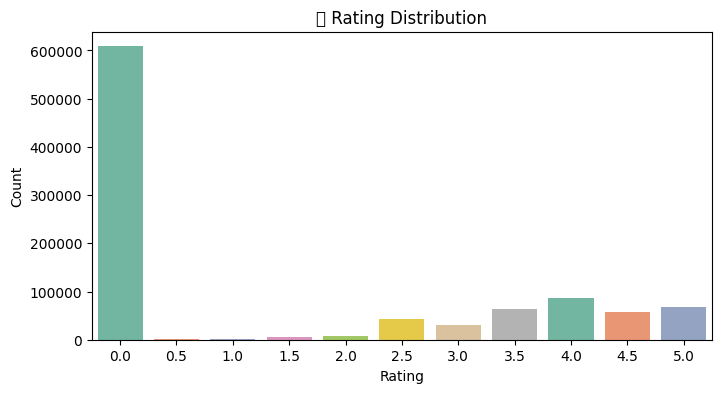

In [ ]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df_analysis, x='Rating', palette='Set2')
plt.title("📊 Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


In [ ]:
print(type(plt))


<class 'module'>


In [ ]:
print("Unique ratings:", df_analysis['Rating'].nunique())
print("Rating values:", df_analysis['Rating'].unique())
print(df_analysis['Rating'].value_counts().sort_index())


Unique ratings: 11
Rating values: [0.  2.5 3.  3.5 5.  4.5 1.5 4.  2.  1.  0.5]
Rating
0.0    608301
0.5      1395
1.0      2207
1.5      4825
2.0      7103
2.5     42990
3.0     29902
3.5     62749
4.0     86830
4.5     57723
5.0     67802
Name: count, dtype: int64


## top 5 publishers for visibility

C:\Users\aditya.kaushal\AppData\Local\Temp\ipykernel_83180\768466773.py:12: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
e:\GitHub Repo's\Multi_domain_Recommendation\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


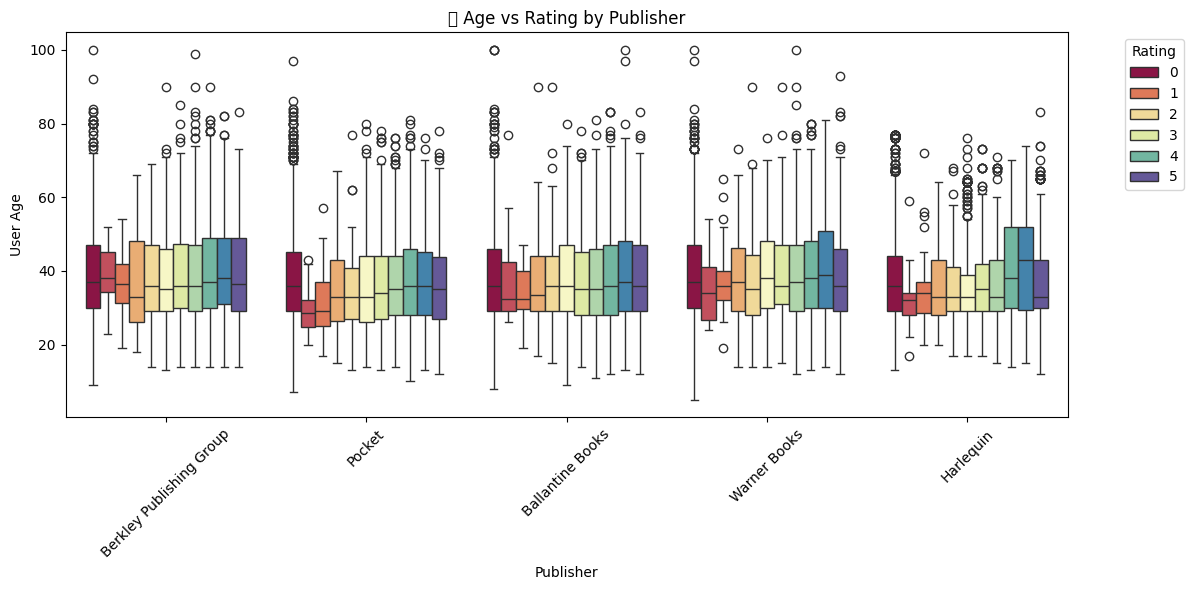

In [ ]:
# Filter: Only top 5 publishers for visibility
top_publishers = df_analysis['Publisher'].value_counts().head(5).index
filtered_df = df_analysis[df_analysis['Publisher'].isin(top_publishers) & df_analysis['Age'].between(5, 100)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=filtered_df, x='Publisher', y='Age', hue='Rating', palette='Spectral')
plt.title("📊 Age vs Rating by Publisher")
plt.xlabel("Publisher")
plt.ylabel("User Age")
plt.legend(title="Rating", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\aditya.kaushal\AppData\Local\Temp\ipykernel_83180\1174569380.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_analysis[df_analysis['Publisher'].isin(top_publishers)].pivot_table(
e:\GitHub Repo's\Multi_domain_Recommendation\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


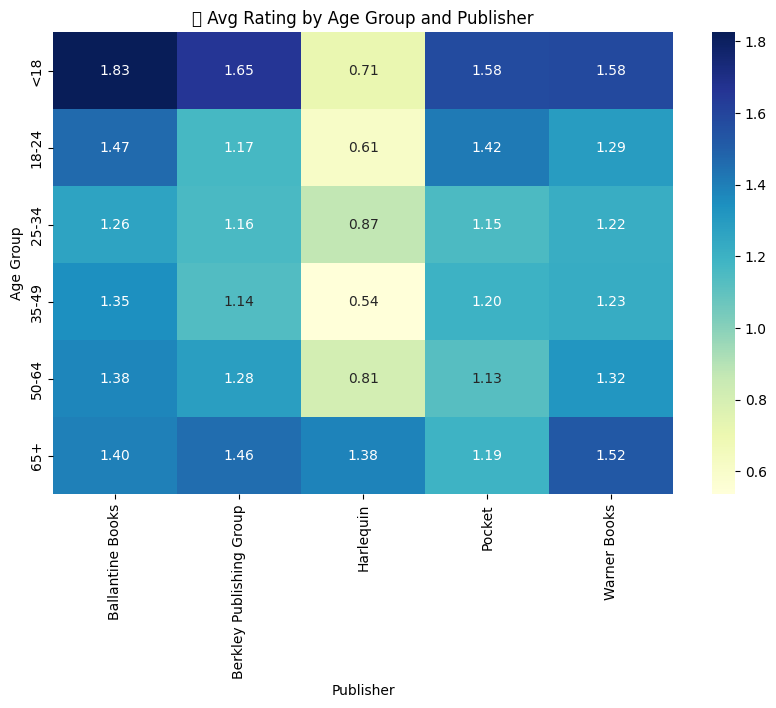

In [ ]:
# Create age groups
age_bins = [0, 18, 25, 35, 50, 65, 100]
age_labels = ['<18', '18-24', '25-34', '35-49', '50-64', '65+']
df_analysis['AgeGroup'] = pd.cut(df_analysis['Age'], bins=age_bins, labels=age_labels, right=False)

# Pivot table
pivot = df_analysis[df_analysis['Publisher'].isin(top_publishers)].pivot_table(
    values='Rating', index='AgeGroup', columns='Publisher', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='YlGnBu')
plt.title("🔥 Avg Rating by Age Group and Publisher")
plt.xlabel("Publisher")
plt.ylabel("Age Group")
plt.show()


##  Rating Distribution by Age Group

C:\Users\aditya.kaushal\AppData\Local\Temp\ipykernel_83180\3203238692.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analysis[df_analysis['Rating'] > 0], x='AgeGroup', y='Rating', palette='pastel')
e:\GitHub Repo's\Multi_domain_Recommendation\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


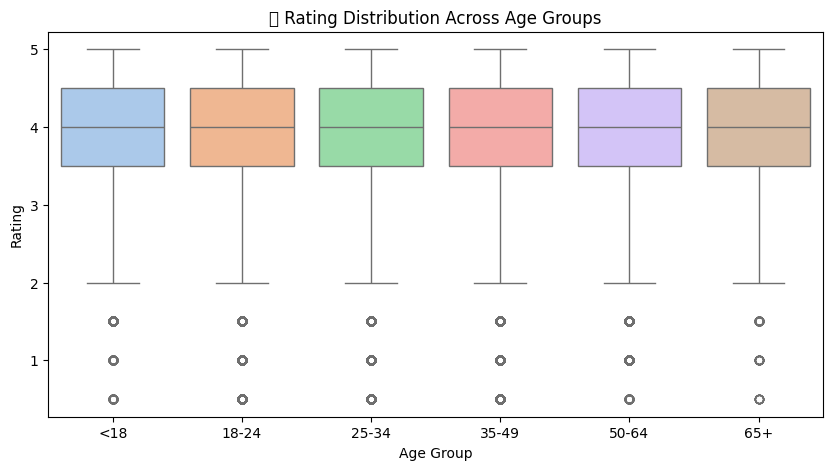

In [ ]:
# Create age groups
age_bins = [0, 18, 25, 35, 50, 65, 100]
age_labels = ['<18', '18-24', '25-34', '35-49', '50-64', '65+']
df_analysis['AgeGroup'] = pd.cut(df_analysis['Age'], bins=age_bins, labels=age_labels, right=False)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_analysis[df_analysis['Rating'] > 0], x='AgeGroup', y='Rating', palette='pastel')
plt.title("📦 Rating Distribution Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Rating")
plt.show()


- According to graphs we can see that in each bins(age range) the distibution of rating is same.
- Mathematically, this suggests that the age of a user doesn't significantly influence their rating behavior.

## Strip Plot: Age vs Rating (Sampled)

e:\GitHub Repo's\Multi_domain_Recommendation\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


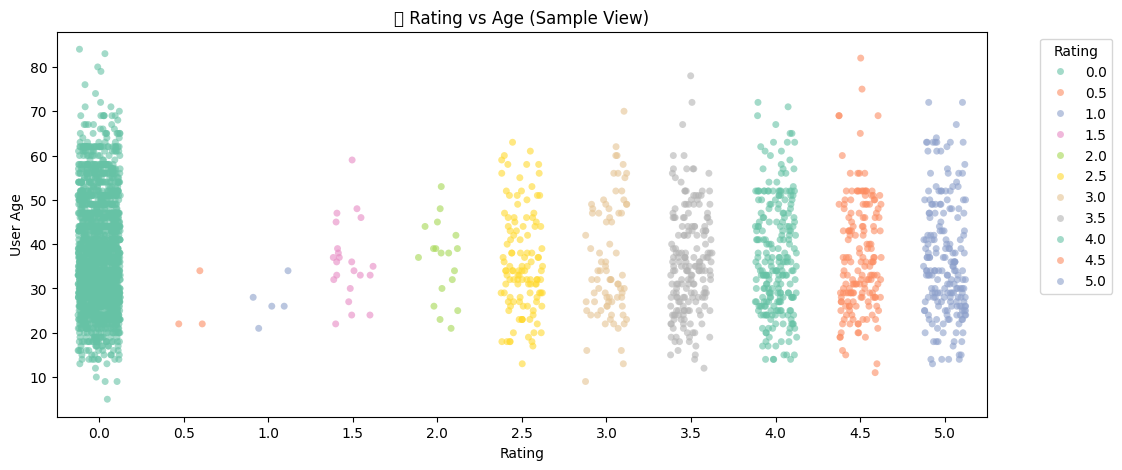

In [ ]:
plt.figure(figsize=(12, 5))
sns.stripplot(
    data=df_analysis[df_analysis['Age'].between(5, 100)].sample(3000),
    x='Rating', y='Age', hue='Rating', palette='Set2', jitter=0.25, alpha=0.6
)
plt.title("📌 Rating vs Age (Sample View)")
plt.xlabel("Rating")
plt.ylabel("User Age")
plt.legend(title="Rating", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


# Saving the Clean Table in the processed data


In [ ]:
df_user.head()

,User-ID,Age
0,1,NaN
1,2,18.0
2,3,NaN
3,4,17.0
4,5,NaN


In [ ]:
df_user['User-ID'].nunique()


278859

In [ ]:
import pandas as pd

# Assume your DataFrame is named df and the ISBN column is 'ISBN'
# Step 1: Create a mapping from ISBN to a unique integer ID
isbn_to_id = {isbn: idx for idx, isbn in enumerate(df['ISBN'].unique(), start=1)}

# Step 2: Map the ISBN column to the new integer IDs
df_rating['book_id'] = df_rating['ISBN'].map(isbn_to_id)

# Now df['book_id'] contains unique integers from 1 to n
print(df[['ISBN', 'book_id']].head())

         ISBN  book_id
0  034545104X        1
1  0155061224        2
2  0446520802        3
3  052165615X        4
4  0521795028        5


In [92]:
df['ISBN'].value_counts()


ISBN
0971880107    2502
0316666343    1295
0385504209     883
0060928336     732
0312195516     723
              ... 
0671883917       1
0743257502       1
0767409752       1
0785263195       1
0802141358       1
Name: count, Length: 340556, dtype: int64

In [91]:
(df['book_id'].value_counts() > 70).sum()


np.int64(1277)

In [93]:
df_rating.head()

,User-ID,ISBN,Rating
0,276725,034545104X,0.0
1,276726,0155061224,2.5
2,276727,0446520802,0.0
3,276729,052165615X,1.5
4,276729,0521795028,3.0


In [95]:
# STEP 1: Ensure ISBNs are cleaned consistently
for df in [df_rating, df_book]:
    df['ISBN'] = df['ISBN'].str.strip().str.upper()

# STEP 2: Create unique mapping from ISBN to book_id using df_rating
isbn_to_id = {isbn: idx for idx, isbn in enumerate(df_rating['ISBN'].unique(), start=1)}

# STEP 3: Apply the same mapping to all DataFrames
df_rating['book_id'] = df_rating['ISBN'].map(isbn_to_id)
df_book['book_id']   = df_book['ISBN'].map(isbn_to_id)
# df_info['book_id']   = df_info['ISBN'].map(isbn_to_id)


In [109]:
df_user2=pd.read_csv(r"E:\GitHub Repo's\Multi_domain_Recommendation\data\processed\movie\movie_user.csv")

In [114]:
df_book.head()


,ISBN,Title,Author,Year,Publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton & Company


In [118]:
# Assuming your DataFrames are named as:
# df_user: contains the valid user_ids
# df_rating: contains all ratings (e.g., book/movie/music)
# df_book = pd.read_csv("../data/raw/book/Books.csv", sep=";")
# df_rating = pd.read_csv("../data/raw/book/Ratings.csv", sep=";")
# df_user = pd.read_csv("../data/raw/book/Users.csv", sep=";")

valid_user_ids = df_user2['user_id'].unique()
filtered_ratings = df_rating[df_rating['User-ID'].isin(valid_user_ids)]
# filtered_info = df_book[df_rating['User-ID'].isin(valid_user_ids)]
filtered_user = df_user[df_rating['User-ID'].isin(valid_user_ids)]



C:\Users\aditya.kaushal\AppData\Local\Temp\ipykernel_83180\1030386817.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_user = df_user[df_rating['User-ID'].isin(valid_user_ids)]


In [120]:
filtered_ratings.head()

,User-ID,ISBN,Rating
9561,2,0195153448,0
9562,7,034542252,0
9563,8,0002005018,5
9564,8,0060973129,0
9565,8,0374157065,0


In [124]:
df_book.head()

,ISBN,Title,Author,Year,Publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton & Company


In [125]:

valid_book_ids = filtered_ratings['User-ID'].unique()
filtered_info = df_book[df_book['ISBN'].isin(valid_user_ids)]
# filtered_info = df_book[df_rating['User-ID'].isin(valid_user_ids)]
# filtered_user = df_user[df_rating['User-ID'].isin(valid_user_ids)]

In [128]:
filtered_ratings.head()

,User-ID,ISBN,Rating
9561,2,0195153448,0
9562,7,034542252,0
9563,8,0002005018,5
9564,8,0060973129,0
9565,8,0374157065,0


In [126]:
filtered_info.head()

,ISBN,Title,Author,Year,Publisher


In [127]:
filtered_info.shape

(0, 5)

In [105]:
filtered_ratings.shape

(2456, 4)

In [106]:
filtered_ratings.head()

,User-ID,ISBN,Rating,book_id
9561,2,0195153448,0.0,8968
9562,7,034542252,0.0,8969
9563,8,0002005018,2.5,8970
9564,8,0060973129,0.0,8971
9565,8,0374157065,0.0,8972


In [116]:
base_path = r"E:\GitHub Repo's\Multi_domain_Recommendation\data\processed"

# Define datasets per domain
datasets = {
    "book": {
        "book_user":df_user,
        "book_info": df_book,
        "book_rating": df_rating,
        "book_filtered_rating": filtered_ratings,
        "book_filtered_user":filtered_user,
        'book_filtered_info': filtered_info

    }
}

# Save each table in its domain folder
for domain, tables in datasets.items():
    domain_path = os.path.join(base_path, domain)
    os.makedirs(domain_path, exist_ok=True)
    
    for table_name, df in tables.items():
        file_path = os.path.join(domain_path, f"{table_name}.csv")
        df.to_csv(file_path, index=False)
        print(f"✅ Saved: {file_path}")


NameError: name 'filtered_info' is not defined

In [ ]:
df_book = pd.read_csv("../data/raw/book/Books.csv", sep=";")
df_rating = pd.read_csv("../data/raw/book/Ratings.csv", sep=";")
df_user = pd.read_csv("../data/raw/book/Users.csv", sep=";")